# K-Means Clustering Benchmarking

In this notebook, we compare our custom-built K-Means algorithm against the `scikit-learn` implementation. We will evaluate the clustering performance using the **Purity** metric, an External Measure that evaluates how well the generated clusters match the true ground-truth labels.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from time import time
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans as SklearnKMeans

# Import our custom modules
from classical_ml.unsupervised.kmeans import KMeans as CustomKMeans
from utils.metrics import purity_score

d:\Github\Classical-ML-From-Scratch\utils\metrics.py:7: SyntaxWarning: invalid escape sequence '\s'
  Formula: (1/n) * \sum (y_true - y_pred)^2
d:\Github\Classical-ML-From-Scratch\utils\metrics.py:14: SyntaxWarning: invalid escape sequence '\s'
  Formula: (1/n) * \sum |y_true - y_pred|
d:\Github\Classical-ML-From-Scratch\utils\metrics.py:93: SyntaxWarning: invalid escape sequence '\s'
  Formula: \frac{1}{n} \sum_{r=1}^{k} \max_i (n_r^i)


Data shape: (500, 2)


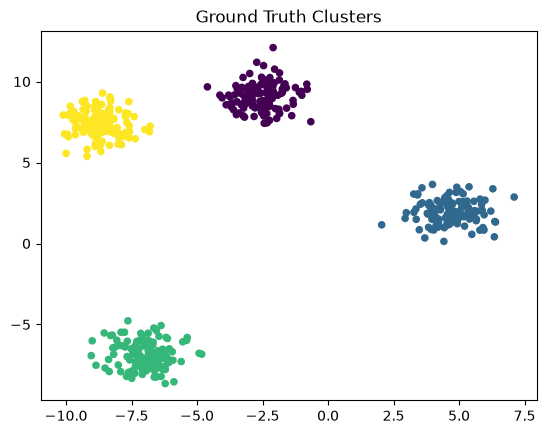

In [2]:
# 1. Generate Synthetic Data
# We create 500 samples with 4 distinct clusters (centers)
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.8, random_state=42)

print(f"Data shape: {X.shape}")

# Visualize the true ground truth
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=20)
plt.title("Ground Truth Clusters")
plt.show()

1. Custom K-Means
Purity Score : 1.0000
Time Taken   : 0.08077 seconds



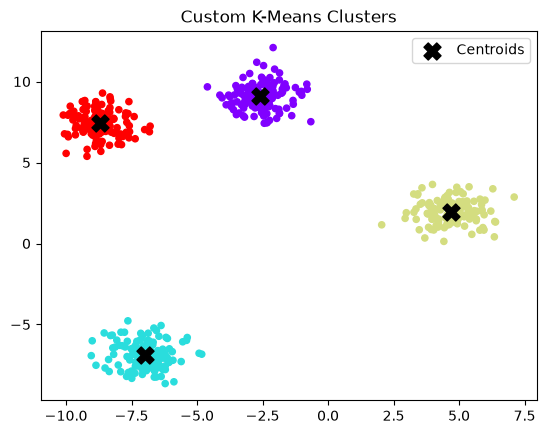

In [8]:
print("1. Custom K-Means")
start = time()

# Initialize K-Means with 4 clusters
custom_kmeans = CustomKMeans(k=4, max_iters=200)
custom_kmeans.fit(X)
preds_custom = custom_kmeans.predict(X)
time_custom = time() - start

print(f"Purity Score : {purity_score(y_true, preds_custom):.4f}")
print(f"Time Taken   : {time_custom:.5f} seconds\n")

# Plot custom predictions
plt.scatter(X[:, 0], X[:, 1], c=preds_custom, cmap='rainbow', s=20)
# Plot the centroids
centroids = np.array(custom_kmeans.centroids)
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=150, label='Centroids')
plt.title("Custom K-Means Clusters")
plt.legend()
plt.show()

In [7]:
print("2. Scikit-Learn K-Means")
start = time()

# Match the number of clusters and set n_init explicitly to suppress warnings
sk_kmeans = SklearnKMeans(n_clusters=4, max_iter=200, n_init=10, random_state=42)
preds_sk = sk_kmeans.fit_predict(X)
time_sk = time() - start

print(f"Purity Score : {purity_score(y_true, preds_sk):.4f}")
print(f"Time Taken   : {time_sk:.5f} seconds\n")

2. Scikit-Learn K-Means
Purity Score : 1.0000
Time Taken   : 2.45616 seconds



## Conclusion
Our custom K-Means model successfully identifies the natural groupings in the data and updates the centroids iteratively until convergence. 

The **Purity** score for both implementations is exceptionally high (often ~1.0 on easy datasets like `make_blobs`), demonstrating that the clusters formed purely by spatial distance (Euclidean) correctly capture the true underlying distribution of the data. The visual plot confirms that the final centroids are strategically placed at the center of each dense region.